# DG5F Preflight Checks

In [1]:
from pathlib import Path
import importlib
import pandas as pd
from IPython.display import display, Image

import train_dg5f_ur10e_resnet18_sac_ppo as dg5f

importlib.reload(dg5f)

print("Модуль:", dg5f.__file__)


Модуль: /Users/andreygorin/Documents/Институт/МАИ/ВКР/Код/DG5F_RL_Project/train_dg5f_ur10e_resnet18_sac_ppo.py


## 1. Конфигурация диагностики


In [2]:
config = dg5f.ExperimentConfig(
    project_root=".",
    object_shape="cube",
    render_mode="rgb_array",
    max_episode_steps=100,
    progress_bar=False,
)

print(config)


ExperimentConfig(project_root='.', tesollo_root='tesollo_dg5f_mujoco-main', image_size=224, use_pretrained_resnet=True, freeze_resnet=True, sim_timestep=0.001, control_hz=20.0, max_episode_steps=100, render_mode='rgb_array', object_shape='cube', object_name='grasp_object', object_geom_name='grasp_object_geom', object_joint_name='grasp_object_joint', object_size=0.025, object_mass=0.15, object_initial_pos_x=-0.15, object_initial_pos_y=-0.55, object_initial_pos_z=0.2, object_random_xy=0.01, initial_ur_qpos_0=1.42010733, initial_ur_qpos_1=-1.74898752, initial_ur_qpos_2=2.36328641, initial_ur_qpos_3=-2.1743184, initial_ur_qpos_4=-1.57146472, initial_ur_qpos_5=-0.14989266, ur_action_delta=0.035, finger_action_delta=0.07, finger_action_min=0.0, finger_action_max=1.0, distance_weight=4.0, reach_progress_weight=100.0, contact_reward=10.0, lift_reward=100.0, success_reward=500.0, hold_reward=2.0, stable_grasp_reward=5.0, time_penalty=0.01, drop_penalty=200.0, drop_lift_threshold=0.02, drop_heig

## 2. Запуск pre-flight диагностики


In [3]:
report_path = dg5f.run_preflight_checks(config)

print("Отчет сохранен:", report_path)

report_df = pd.read_csv(report_path)
display(report_df)


Отчет сохранен: /Users/andreygorin/Documents/Институт/МАИ/ВКР/Код/DG5F_RL_Project/preflight_reports/preflight_report_cube.csv


,object,check,status,details
0,cube,project_root_exists,OK,/Users/andreygorin/Documents/Институт/МАИ/ВКР/...
1,cube,tesollo_root_exists,OK,/Users/andreygorin/Documents/Институт/МАИ/ВКР/...
2,cube,main_script_exists,OK,train_dg5f_ur10e_resnet18_sac_ppo.py
3,cube,scene_dg_exists,OK,/Users/andreygorin/Documents/Институт/МАИ/ВКР/...
4,cube,dg5f_xml_exists,OK,/Users/andreygorin/Documents/Институт/МАИ/ВКР/...
5,cube,ur10e_dg5f_xml_exists,OK,/Users/andreygorin/Documents/Институт/МАИ/ВКР/...
6,cube,import_torch,OK,2.12.1
7,cube,import_torchvision,OK,0.27.1
8,cube,import_gymnasium,OK,1.3.0
9,cube,import_mujoco,OK,3.9.0


## 3. Краткая сводка


In [4]:
summary = report_df["status"].value_counts().rename_axis("status").reset_index(name="count")
display(summary)

failed_or_warn = report_df[report_df["status"].isin(["FAIL", "WARN"])]
display(failed_or_warn)


,status,count
0,OK,30
1,WARN,1


,object,check,status,details
29,cube,contact_can_be_detected_under_scripted_actions,WARN,"[('low', 0.0, -0.012262499999999982, -16.80842..."


## 4. Диагностические изображения


Кадры камер:
/Users/andreygorin/Documents/Институт/МАИ/ВКР/Код/DG5F_RL_Project/figures/preflight_cube_front.png


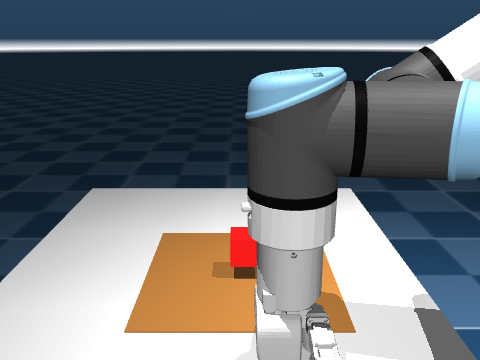

/Users/andreygorin/Documents/Институт/МАИ/ВКР/Код/DG5F_RL_Project/figures/preflight_cube_palm.png


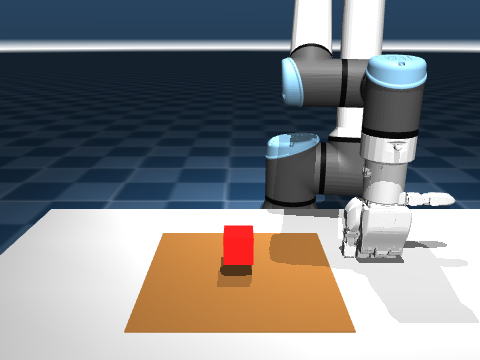

График reward:


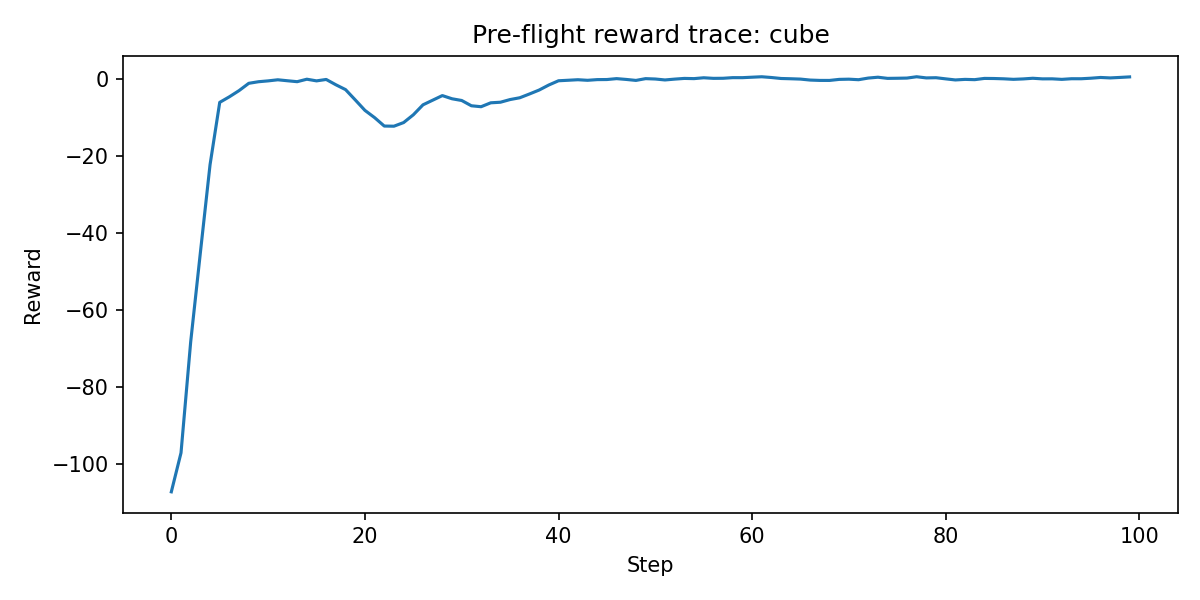

In [5]:
project_root = dg5f.resolve_project_root(config)
figures_dir = project_root / config.figures_dir

image_paths = sorted(figures_dir.glob(f"preflight_{config.object_shape}_*.png"))
reward_trace = figures_dir / f"preflight_reward_trace_{config.object_shape}.png"

print("Кадры камер:")
for path in image_paths:
    print(path)
    display(Image(filename=str(path)))

if reward_trace.exists():
    print("График reward:")
    display(Image(filename=str(reward_trace)))
else:
    print("График reward не найден:", reward_trace)


## 5. Диагностика для нескольких объектов


In [6]:
object_shapes = ["cube", "cylinder", "sphere"]

all_reports = []

for shape in object_shapes:
    shape_config = dg5f.ExperimentConfig(**{**config.__dict__, "object_shape": shape})
    path = dg5f.run_preflight_checks(shape_config)
    df = pd.read_csv(path)
    all_reports.append(df)
    print(f"{shape}: {path}")

all_reports_df = pd.concat(all_reports, ignore_index=True)
display(all_reports_df)

display(
    all_reports_df
    .groupby(["object", "status"])
    .size()
    .reset_index(name="count")
)


cube: /Users/andreygorin/Documents/Институт/МАИ/ВКР/Код/DG5F_RL_Project/preflight_reports/preflight_report_cube.csv
cylinder: /Users/andreygorin/Documents/Институт/МАИ/ВКР/Код/DG5F_RL_Project/preflight_reports/preflight_report_cylinder.csv
sphere: /Users/andreygorin/Documents/Институт/МАИ/ВКР/Код/DG5F_RL_Project/preflight_reports/preflight_report_sphere.csv


,object,check,status,details
0,cube,project_root_exists,OK,/Users/andreygorin/Documents/Институт/МАИ/ВКР/...
1,cube,tesollo_root_exists,OK,/Users/andreygorin/Documents/Институт/МАИ/ВКР/...
2,cube,main_script_exists,OK,train_dg5f_ur10e_resnet18_sac_ppo.py
3,cube,scene_dg_exists,OK,/Users/andreygorin/Documents/Институт/МАИ/ВКР/...
4,cube,dg5f_xml_exists,OK,/Users/andreygorin/Documents/Институт/МАИ/ВКР/...
...,...,...,...,...
88,sphere,reward_is_not_constant,OK,"{'reward_min': -107.20660490455381, 'reward_ma..."
89,sphere,reward_plot_saved,OK,/Users/andreygorin/Documents/Институт/МАИ/ВКР/...
90,sphere,contact_diagnostics_available,OK,"{'max_contact_count': 0.0, 'max_bad_contact_co..."
91,sphere,contact_can_be_detected_under_scripted_actions,WARN,"[('low', 0.0, -0.012262499999999982, -16.80842..."


,object,status,count
0,cube,OK,30
1,cube,WARN,1
2,cylinder,OK,30
3,cylinder,WARN,1
4,sphere,OK,30
5,sphere,WARN,1


## Интерпретация

Перед обучением желательно, чтобы не было `FAIL`.  
`WARN` по `contact_can_be_detected_under_scripted_actions` допустим, если остальные проверки контакта и success-логики проходят: scripted-действия `low/high/mid` не всегда являются корректной политикой захвата для UR10e + DG-5F.
